In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

/tmp/ipykernel_1169/764406064.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1169/764406064.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

In [7]:
X = df[['Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked']]

y = df['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [9]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [12]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[92 13]
 [19 55]]


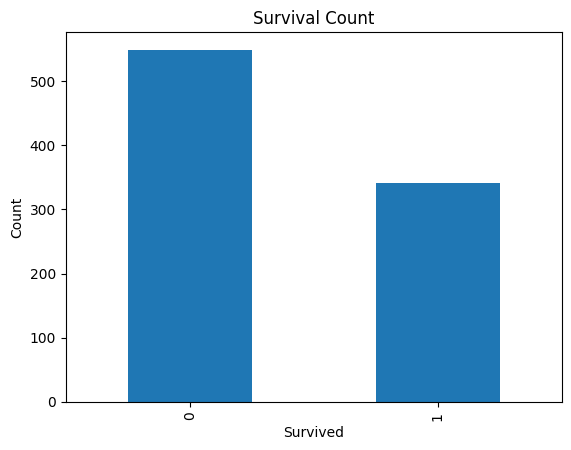

In [13]:
df['Survived'].value_counts().plot(kind='bar')

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

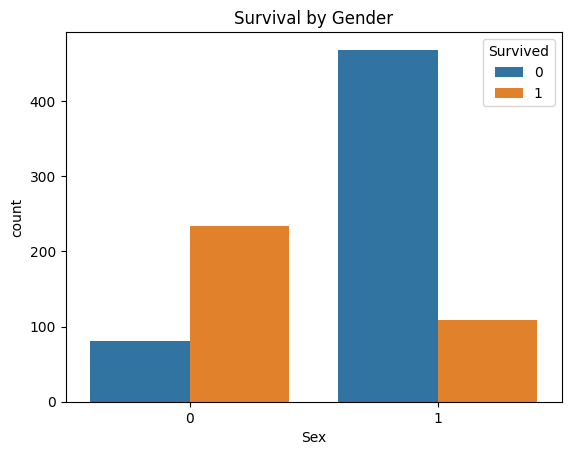

In [14]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

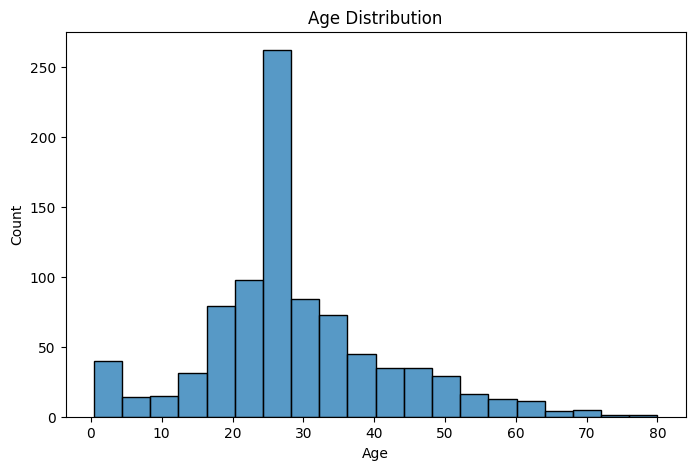

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


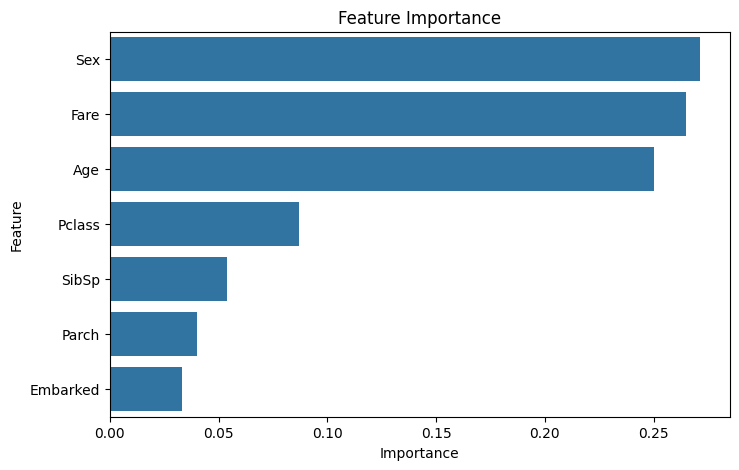

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()